In [1]:
import torch
import torch.nn as nn

device = "cuda"

torch.manual_seed(42)
encoder = nn.Linear(3,2)
decoder = nn.Linear(2,3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

In [2]:
from pathlib import Path
from torchvision import datasets, transforms

DATA_DIR = Path("datasets")

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(len(train_dataset), len(test_dataset))

60000 10000


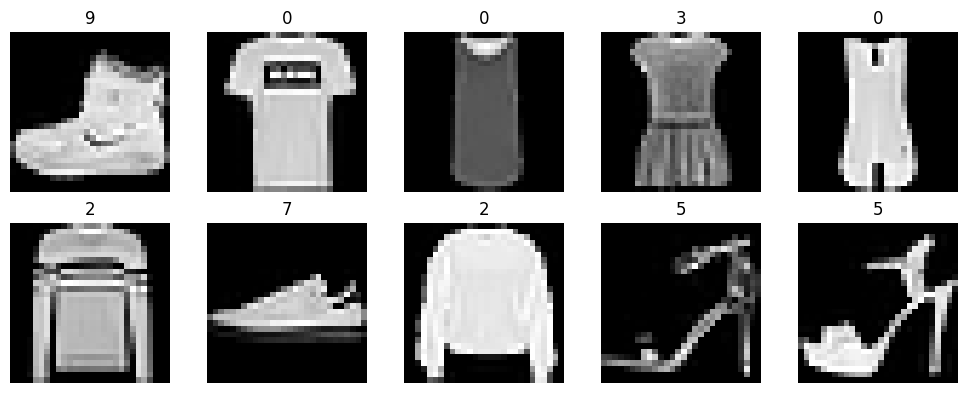

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
from typing import Any

from torch.utils.data import DataLoader

class SetInputAsLabel():
    def __call__(self, batch):
        X = torch.stack([x for x, y in batch])
        return X,X
    
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, pin_memory=True, collate_fn=SetInputAsLabel())
test_loader = DataLoader(test_dataset, batch_size=32, drop_last=True, pin_memory=True, collate_fn=SetInputAsLabel())

In [5]:
from torch.optim import AdamW


class InhuAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        stacked_encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1 * 28 * 28, 128),
        nn.Linear(128, 32), nn.ReLU()
        )

        stacked_decoder = nn.Sequential(
        nn.Linear(32, 128), nn.ReLU(),
        nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
        nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
        )

        self.stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder)
    
    def forward(self, X):
        return self.stacked_ae(X)

model = InhuAutoEncoder().to(device)
optimizer = AdamW(model.parameters())

def train(model, optimizer:torch.optim.Optimizer, loss_fn, epoch:int, train_loader:DataLoader, test_loader:DataLoader):
    epoch_loss_list:list[float] = []
    epoch_test_loss_list:list[float] = []
    
    for epoch_idx in range(epoch):
        model.train()
        epoch_loss:float = 0
        epoch_test_loss:float = 0
        for x, _ in train_loader:
            optimizer.zero_grad()
            
            x = x.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, x)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        with torch.no_grad():
             model.eval()
             
             for x, _ in test_loader:
                x = x.to(device)
                y_pred = model(x)
                test_loss = loss_fn(y_pred, x)
                epoch_test_loss += test_loss
        

        epoch_loss_list.append(epoch_loss / len(train_loader))
        epoch_test_loss_list.append(epoch_test_loss / len(test_loader))
        print(f"epoch {epoch_idx}, train loss : {epoch_loss_list[epoch_idx]}, test loss : {epoch_test_loss_list[epoch_idx]}")
    
    return epoch_loss_list, epoch_test_loss_list



In [ ]:
train_loss, test_loss = train(model, optimizer, nn.MSELoss(), 30, train_loader, test_loader)

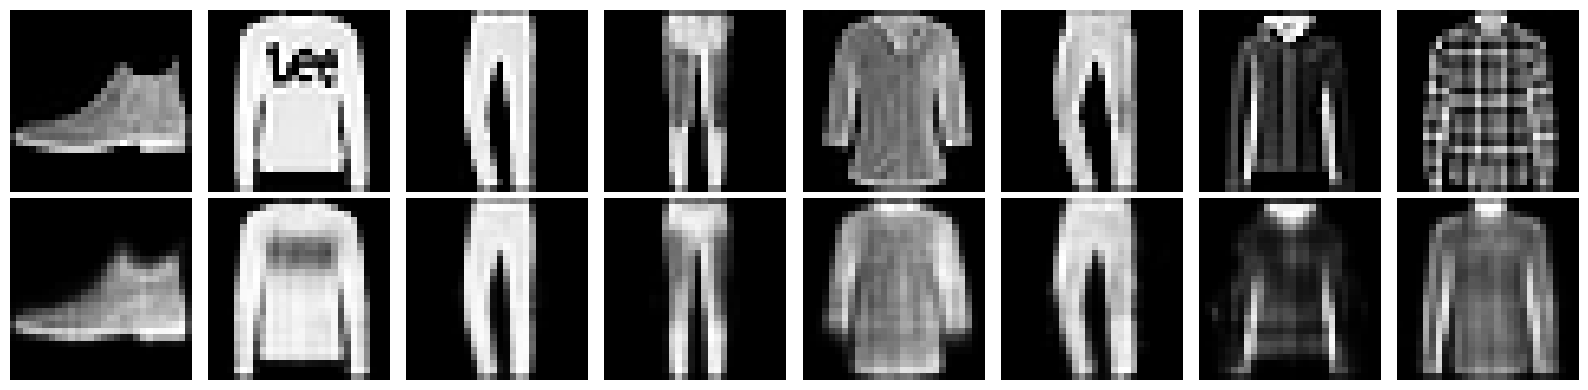

In [11]:
import torch
import matplotlib.pyplot as plt

n = 8
images = torch.stack([test_dataset[i][0] for i in range(n)]).to(device)

model.eval()
with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstructed")
plt.tight_layout()
plt.show()


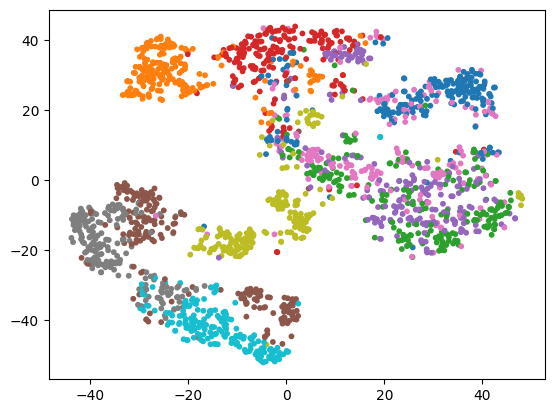

In [ ]:
from sklearn.manifold import TSNE

n = 2000  # TSNE gets slow on the full 10,000 test images, so sample a subset
X_valid = torch.stack([test_dataset[i][0] for i in range(n)])
y_valid = torch.tensor([test_dataset[i][1] for i in range(n)])

encoder = model.stacked_ae[0]  # the stacked_encoder Sequential inside InhuAutoEncoder
encoder.eval()
with torch.no_grad():
    X_valid_compressed = encoder(X_valid.to(device))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()

In [7]:
conv_encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), #[16, 14, 14]
    nn.Conv2d(16, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), #[32, 7, 7]
    nn.Conv2d(32, 64, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), #[64, 3, 3]
    nn.Conv2d(64, 32, kernel_size=3, padding="same"), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
)

conv_decoder = nn.Sequential(
    nn.Linear(32, 16 * 3 * 3),
    nn.Unflatten(dim = 1, unflattened_size=(16,3,3)),
    nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
)

conv_ae = nn.Sequential(conv_encoder, conv_decoder).to(device)

In [8]:
import torch.nn.functional as F

class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(1*28*28,128)
        self.enc2 = nn.Linear(128, 32)
        self.dec1_bias = nn.Parameter(torch.zeros(128))
        self.dec2_bias = nn.Parameter(torch.zeros(1*28*28))
    
    def encode(self,X):
        Z = X.view(-1, 1*28*28)
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))
    
    def decode(self, X):
        Z = F.relu(F.linear(X, self.enc2.weight.t(), self.dec1_bias))
        Z = F.sigmoid(F.linear(Z, self.enc1.weight.t(), self.dec2_bias))
        return Z.view(-1, 1, 28, 28)
    
    def forward(self, X):
        return self.decode(self.encode(X))

In [9]:
dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1*28*28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU()
)

dropout_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1*28*28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1,28,28))
)

dropout_ae = nn.Sequential(dropout_encoder, dropout_decoder).to(device)

# variational autoencoder

In [11]:
from collections import namedtuple

VAEOutput = namedtuple("VAEOutput", ["output", "codings_mean", "codings_logvar"])

class VAE(nn.Module):
    def __init__(self, codings_dim=32):
        super().__init__()
        self.codings_dim = codings_dim

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2 * codings_dim),  # mean + logvar
        )

        self.decoder = nn.Sequential(
            nn.Linear(codings_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1 * 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)),
        )

    def encode(self, X):
        return self.encoder(X).chunk(2, dim=-1)  # (mean, logvar)

    def sample_codings(self, codings_mean, codings_logvar):
        codings_std = torch.exp(0.5 * codings_logvar)
        noise = torch.randn_like(codings_std)
        return codings_mean + noise * codings_std

    def decode(self, Z):
        return self.decoder(Z)

    def forward(self, X):
        codings_mean, codings_logvar = self.encode(X)
        codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(codings)
        return VAEOutput(output, codings_mean, codings_logvar)

In [12]:
from torch import Tensor


def vae_loss(y_pred:Tensor, y_target:Tensor, kl_weight=1.0):
    output, mean, logvar = y_pred
    kl_div = -0.5 * torch.sum(1 + logvar - logvar.exp() - mean.square(), dim=-1)
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

torch.manual_seed(42)
vae = VAE().to(device)
optimizer = torch.optim.NAdam(vae.parameters(), lr=1e-3)
train(vae, optimizer, vae_loss, epoch=20, train_loader=train_loader, test_loader=test_loader)
    

epoch 0, train loss : 0.0480933948079745, test loss : 0.03873724490404129
epoch 1, train loss : 0.03663348930478096, test loss : 0.035018935799598694
epoch 2, train loss : 0.03450778702795505, test loss : 0.03405136615037918
epoch 3, train loss : 0.03364007241825263, test loss : 0.03337930887937546
epoch 4, train loss : 0.03310849913060665, test loss : 0.032908909022808075
epoch 5, train loss : 0.032728509133060774, test loss : 0.0325060710310936
epoch 6, train loss : 0.032462135577201845, test loss : 0.032263223081827164
epoch 7, train loss : 0.03227254414856434, test loss : 0.03218456730246544
epoch 8, train loss : 0.032107897539933525, test loss : 0.0320923887193203
epoch 9, train loss : 0.03199391628702482, test loss : 0.03207344934344292
epoch 10, train loss : 0.03189159518678983, test loss : 0.031981777399778366
epoch 11, train loss : 0.0317990323672692, test loss : 0.03190698102116585
epoch 12, train loss : 0.03173359426160653, test loss : 0.031773682683706284
epoch 13, train lo

([0.0480933948079745,
  0.03663348930478096,
  0.03450778702795505,
  0.03364007241825263,
  0.03310849913060665,
  0.032728509133060774,
  0.032462135577201845,
  0.03227254414856434,
  0.032107897539933525,
  0.03199391628702482,
  0.03189159518678983,
  0.0317990323672692,
  0.03173359426160653,
  0.031701755148172375,
  0.03163822760879993,
  0.031589583415786424,
  0.031558801204959554,
  0.03152803662618001,
  0.031498157655199366,
  0.03144776065150897],
 [tensor(0.0387, device='cuda:0'),
  tensor(0.0350, device='cuda:0'),
  tensor(0.0341, device='cuda:0'),
  tensor(0.0334, device='cuda:0'),
  tensor(0.0329, device='cuda:0'),
  tensor(0.0325, device='cuda:0'),
  tensor(0.0323, device='cuda:0'),
  tensor(0.0322, device='cuda:0'),
  tensor(0.0321, device='cuda:0'),
  tensor(0.0321, device='cuda:0'),
  tensor(0.0320, device='cuda:0'),
  tensor(0.0319, device='cuda:0'),
  tensor(0.0318, device='cuda:0'),
  tensor(0.0318, device='cuda:0'),
  tensor(0.0316, device='cuda:0'),
  tensor(

In [13]:
torch.manual_seed(42)
vae.eval()
codings = torch.randn(3 * 7, vae.codings_dim, device=device)
with torch.no_grad():
    images = vae.decode(codings)

In [14]:
codings = torch.randn(2, vae.codings_dim)  # start and end codings
n_images = 7
weights = torch.linspace(0, 1, n_images).view(n_images, 1)
codings = torch.lerp(codings[0], codings[1], weights)  # linear interpolation
with torch.no_grad():
    images = vae.decode(codings.to(device))

In [ ]:
DiscreteVAEOutput = namedtuple("DiscreteVAEOutput", ["output", "logits", "codings_prob"])

class DiscreteVAE(nn.Module):
    def __init__(self, coding_length=32, n_codes=16, temperature=1.0):
        super().__init__()
        self.coding_length = coding_length
        self.n_codes = n_codes
        self.temperature = temperature
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1*28*28, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, coding_length * n_codes),
            nn.Unflatten(dim=1, unflattened_size=(coding_length, n_codes))
        )
        
        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(coding_length * n_codes, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 28*28), nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1,28,28))
        )
        
    def forward(self, X:Tensor) ->DiscreteVAEOutput:
        logits = self.encoder(X)
        codings_prob = F.gumbel_softmax(logits, tau=self.temperature, hard=True)
        output = self.decoder(codings_prob)
        return DiscreteVAEOutput(output, logits, codings_prob)